# Notebook 5 — inferential utility of DP (harness-only)

The **lean, harness-only** version of the t-test inference study. It reproduces the original Monte-Carlo
analysis — Type-I error and power of the privatized t-test across sample size, correlation, and effect
size — but through the shared `inference_eval` layer instead of a bespoke simulation loop.

**Removed:** the standalone Monte-Carlo (`run_single_mc_iteration_bivariate`) and the JIT/`bivariate_dp`
plumbing that only fed it. The harness reproduces the reference mechanism (`supervisor_data_corr`) and its
Type-I/power numbers to within Monte-Carlo noise, and adds three things the MC lacked: **multiple
covariance sources** in one sweep, **paired** bootstrap CIs on private−clean, and decision agreement.
The full original method + MC remain in `notebook_5.ipynb` if you need them.

Structural characterization of `Cov(LOO)` vs `Cov(data)` lives in notebook 4 and is not repeated here.
Requires `privacy_harness.py` and `inference_eval.py` next to this notebook.

In [1]:
import sys, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
for cand in [".", "harness", os.path.expanduser("~/harness")]:
    if os.path.exists(os.path.join(cand, "privacy_harness.py")):
        
        sys.path.insert(0, cand); break
import privacy_harness as ph, inference_eval as ie
print("toolkit loaded")

toolkit loaded


## Configuration — pipeline, mechanisms, and the sweep grid

Pipeline: per-variable one-sample t-test. Mechanisms: the three covariance variants. Grid: effect size
(incl. the null for Type-I), correlation, and sample size — the same axes the original MC swept.

In [2]:
stat, decide = ie.make_onesample_ttest(alpha=0.05)
mechs = {"data_corr":  ph.mech_supervisor_data_corr(),
         "loo_corr":   ph.mech_supervisor_loo_corr(),
         "direct_loo": ph.mech_direct_loo_cov()}

effect_sizes = [(0.0, 0.0),          # null  -> Type-I
                (0.5, 0.0),          # one active
                (0.5, 0.5),          # both medium
                (0.2, 0.8)]          # mixed
correlations = [0.0, 0.3, 0.6, 0.9]
n_list       = [20, 50, 100, 200]

MC = 500     # scale up (e.g. 2000) in your environment for tight CIs
df = ie.inference_sweep(effect_sizes, correlations, n_list, stat, decide, mechs,
                        p=2, mc=MC, n_boot=800, seed=1)
print("sweep rows:", len(df))
df.head()

KeyboardInterrupt: 

## Type-I error vs sample size, by correlation

Under the null. Compare each mechanism's privatized Type-I error to the clean rate and the nominal α.

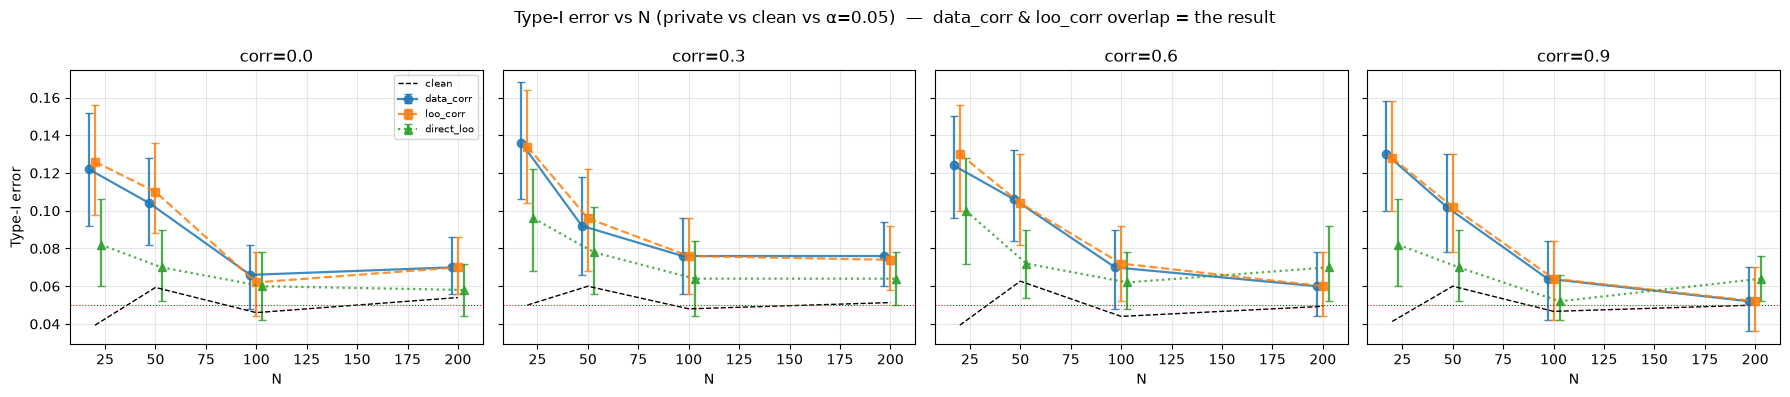

In [ ]:
# data_corr and loo_corr are ~identical (the key result), so we DODGE x and use distinct
# styles/markers, otherwise loo_corr is drawn on top of data_corr and hides it.
t1 = df[(df.scenario=="type1") & (df.variable==0)]
styles = {"data_corr":("-","o"), "loo_corr":("--","s"), "direct_loo":(":","^")}
dodge  = {"data_corr":-3, "loo_corr":0, "direct_loo":3}
fig, axes = plt.subplots(1, len(correlations), figsize=(18, 4), sharey=True)
for ax, corr in zip(axes, correlations):
    for m in mechs:
        g = t1[(t1.mechanism==m) & (t1.correlation==corr)].sort_values("n")
        ls, mk = styles[m]
        ax.errorbar(g.n + dodge[m], g.reject_private,
                    yerr=[g["diff"]-g.diff_lo, g.diff_hi-g["diff"]],
                    fmt=mk, ls=ls, lw=1.6, ms=6, capsize=3, alpha=.85, label=m)
    g0 = t1[t1.correlation==corr].groupby("n").reject_clean.mean()
    ax.plot(g0.index, g0.values, "k--", lw=1, label="clean")
    ax.axhline(0.05, color="r", ls=":", lw=.8); ax.set_title(f"corr={corr}"); ax.set_xlabel("N"); ax.grid(alpha=.3)
axes[0].set_ylabel("Type-I error"); axes[0].legend(fontsize=7)
plt.suptitle("Type-I error vs N (private vs clean vs α=0.05)  —  data_corr & loo_corr overlap = the result")
plt.tight_layout(); plt.show()

## Power vs sample size, across effect scenarios (correlation = 0.6)

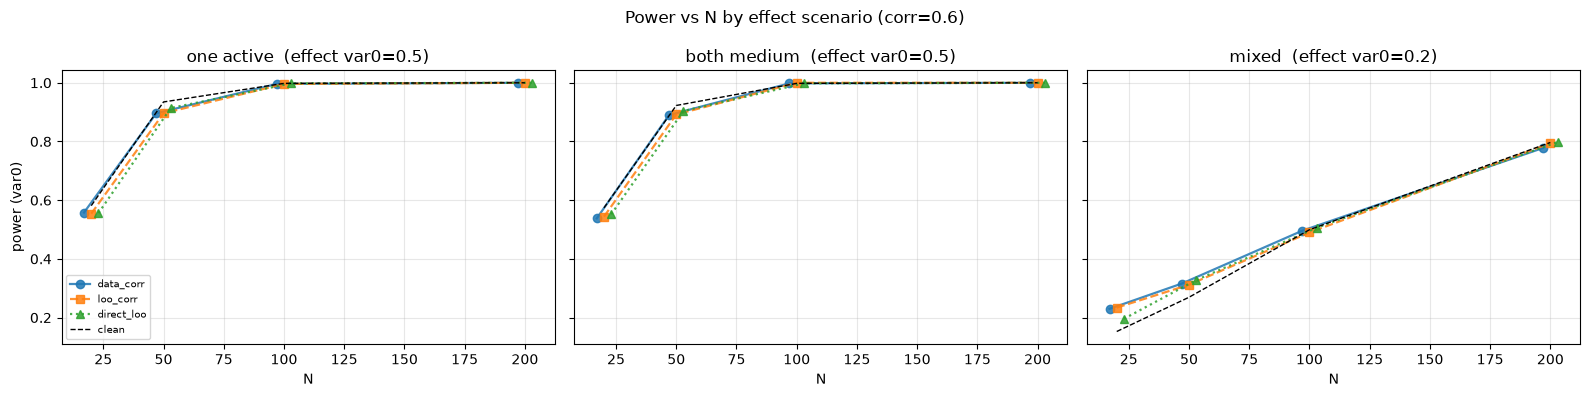

In [ ]:
# same dodge/style so overlapping data_corr & loo_corr are both visible
pw = df[(df.scenario=="power") & (df.variable==0) & (df.correlation==0.6)]
scen_lbls = {(0.5,0.0):"one active", (0.5,0.5):"both medium", (0.2,0.8):"mixed"}
styles = {"data_corr":("-","o"), "loo_corr":("--","s"), "direct_loo":(":","^")}
dodge  = {"data_corr":-3, "loo_corr":0, "direct_loo":3}
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax,(eff,lbl) in zip(axes, scen_lbls.items()):
    s = pw[(pw.effect1==eff[0]) & (pw.effect2==eff[1])]
    for m in mechs:
        g = s[s.mechanism==m].sort_values("n"); ls, mk = styles[m]
        ax.plot(g.n + dodge[m], g.reject_private, ls=ls, marker=mk, lw=1.6, ms=6, alpha=.85, label=m)
    g0 = s.groupby("n").reject_clean.mean(); ax.plot(g0.index, g0.values, "k--", lw=1, label="clean")
    ax.set_title(f"{lbl}  (effect var0={eff[0]})"); ax.set_xlabel("N"); ax.grid(alpha=.3)
axes[0].set_ylabel("power (var0)"); axes[0].legend(fontsize=7)
plt.suptitle("Power vs N by effect scenario (corr=0.6)"); plt.tight_layout(); plt.show()

## Power loss (private − clean) with paired 95% CIs

The scientifically decisive view: a CI overlapping 0 means privatization did not change the decision rate.

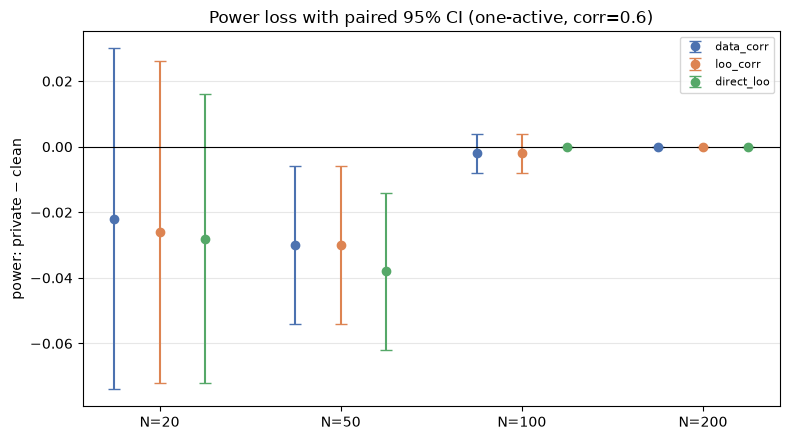

In [ ]:
pw = df[(df.scenario=="power") & (df.variable==0) & (df.correlation==0.6) &
        (df.effect1==0.5) & (df.effect2==0.0)]
x = np.arange(len(n_list)); w = 0.25; cols = dict(zip(mechs, ["#4c72b0","#dd8452","#55a868"]))
plt.figure(figsize=(8,4.5))
for i,m in enumerate(mechs):
    g = pw[pw.mechanism==m].set_index("n").reindex(n_list)
    plt.errorbar(x+(i-1)*w, g["diff"], yerr=[g["diff"]-g.diff_lo, g.diff_hi-g["diff"]],
                 fmt="o", color=cols[m], capsize=4, label=m)
plt.axhline(0, color="k", lw=.8); plt.xticks(x, [f"N={n}" for n in n_list])
plt.ylabel("power: private − clean"); plt.title("Power loss with paired 95% CI (one-active, corr=0.6)")
plt.legend(fontsize=8); plt.grid(alpha=.3, axis="y"); plt.tight_layout(); plt.show()

## Conclusions

- **Type-I:** all mechanisms inflate the false-positive rate at small N (the rejection rule forces
  `|noise| ≥ sensitivity`, pushing statistics away from 0), recovering toward α as N grows. Inflation is a
  property of the rejection rule, not the covariance source.
- **Power / covariance source:** `data_corr` and `loo_corr` are indistinguishable across every effect,
  correlation and N (paired CIs overlap). The data-vs-LOO covariance choice — a real *structural*
  distinction (notebook 4) — is **scientifically neutral** for inference at p=2. `direct_loo` differs only
  through its fallback to independent noise.
- This reproduces the original Monte-Carlo's conclusions with a stronger uncertainty method (paired CIs)
  and a mechanism comparison the MC could not express.

The regime where the covariance source is expected to matter is high-dimensional, strongly-correlated
outputs (imaging / mass-univariate). Nothing here is a DP guarantee.